### Notebook: 03_BERTopic_DistilBERT.ipynb — Clean BERTopic (DistilBERT) on 20NG
**Pipeline:** Clean (stopwords+contractions) → DistilBERT embeddings → BERTopic → export topics → metrics → side-by-side chart.


In [1]:
# ------------------------------------------------------------
# Cell 0 — Environment & folders
# ------------------------------------------------------------
import sys, platform
from pathlib import Path
print("Python exe :", sys.executable); print("Python ver :", platform.python_version())
ROOT=Path(r"C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling"); DATA_DIR=ROOT/"data"; FIG_DIR=ROOT/"figures"
DATA_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Folders:", DATA_DIR, "|", FIG_DIR)


Python exe : c:\Users\murth\Desktop\nlpSession02\codeBase\.venv\Scripts\python.exe
Python ver : 3.10.11
Folders: C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling\data | C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling\figures


### Cell 1 — Load CSV + clean for embeddings (stopwords+contractions)


In [2]:
# ------------------------------------------------------------
# Cell 1 — Load + clean
# ------------------------------------------------------------
import numpy as np, pandas as pd, sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from utils_text import clean_corpus_to_strings, clean_corpus_to_tokens  # both forms

csv = DATA_DIR/"20newsgroups.csv"
df = pd.read_csv(csv)
docs_raw = df["text"].astype(str).tolist()
# For embeddings & BERTopic, we pass cleaned strings:
docs = clean_corpus_to_strings(docs_raw)     # stopwords removed, contractions expanded
# Keep tokens for coherence later:
tokenized = clean_corpus_to_tokens(docs_raw)
print("Docs:", len(docs))


Docs: 6000


### Cell 2 — DistilBERT embedder + BERTopic fit


In [3]:
# ------------------------------------------------------------
# Cell 2 — Fit BERTopic (DistilBERT)
# ------------------------------------------------------------
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

embedder = SentenceTransformer("distilbert-base-nli-mean-tokens")   # cached after first run
topic_model = BERTopic(embedding_model=embedder, calculate_probabilities=True, verbose=True)
topics, probs = topic_model.fit_transform(docs)

valid_topics = [t for t in topics if t != -1]
print("Discovered topics (excl -1):", len(set(valid_topics)), "| Outliers:", sum(t==-1 for t in topics))


c:\Users\murth\Desktop\nlpSession02\codeBase\.venv\lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
2025-09-10 22:53:48,326 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/188 [00:00<?, ?it/s]

2025-09-10 22:59:53,989 - BERTopic - Embedding - Completed ✓
2025-09-10 22:59:53,991 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-09-10 23:00:28,175 - BERTopic - Dimensionality - Completed ✓
2025-09-10 23:00:28,175 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-09-10 23:00:28,895 - BERTopic - Cluster - Completed ✓
2025-09-10 23:00:28,906 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-09-10 23:00:30,183 - BERTopic - Representation - Completed ✓


Discovered topics (excl -1): 9 | Outliers: 114


### Cell 3 — Export BERTopic topics (top terms + exemplar) to CSV


In [4]:
# ------------------------------------------------------------
# Cell 3 — Export BERTopic topics
# ------------------------------------------------------------
import pandas as pd
topics_dict = topic_model.get_topics()  # {tid: [(word, weight), ...]}

# Build preview dataframe
rows=[]; seen_exemplar={}
for i, tid in enumerate(topics):
    if tid == -1: 
        continue
    if tid not in seen_exemplar:
        txt = docs[i].replace("\n"," "); snip = (txt[:180]+" ...") if len(txt)>180 else txt
        seen_exemplar[tid]=(i,snip)

# count docs per topic
from collections import Counter
counts = Counter([t for t in topics if t!=-1])

def top_terms(tid, topn=10):
    return ", ".join([w for (w,wt) in topics_dict.get(tid, [])[:topn]])

valid_ids = sorted([tid for tid in topics_dict if tid!=-1])
for tid in valid_ids:
    ex_i, snip = seen_exemplar.get(tid, (-1,""))
    rows.append({
        "model":"BERTopic",
        "topic_id":tid,
        "n_docs":counts.get(tid,0),
        "top_terms": top_terms(tid, 10),
        "example_doc_idx": ex_i,
        "example_snippet": snip
    })

df_bt = pd.DataFrame(rows).sort_values("n_docs", ascending=False).reset_index(drop=True)
out = DATA_DIR/"bertopic_topics_preview.csv"
df_bt.to_csv(out, index=False, encoding="utf-8"); print("Saved ->", out)


Saved -> C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling\data\bertopic_topics_preview.csv


### Cell 4 — Metrics: Diversity + Coherence (c_v) → append


In [5]:
# ------------------------------------------------------------
# Cell 4 — Diversity + Coherence (c_v) for BERTopic
# ------------------------------------------------------------
import numpy as np, pandas as pd
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# Build topic word lists (exclude -1)
topn = 10
topics_map = topic_model.get_topics()
valid_ids = sorted([tid for tid in topics_map if tid!=-1])
topic_words = [[w for (w,wt) in topics_map[tid][:topn]] for tid in valid_ids if topics_map[tid]]

# diversity
diversity = len(set([w for tw in topic_words for w in tw]))/(len(topic_words)*topn) if topic_words else 0.0
print(f"Topic Diversity (top {topn}): {diversity:.3f}")

# coherence on cleaned tokens
dictionary = Dictionary(tokenized)
corpus = [dictionary.doc2bow(toks) for toks in tokenized]
coh = CoherenceModel(topics=topic_words, texts=tokenized, dictionary=dictionary, coherence="c_v").get_coherence()
print(f"Coherence c_v: {coh:.3f}")

# append
cmp = DATA_DIR/"model_comparison.csv"
row = pd.DataFrame([{"model":"BERTopic","n_topics":len(topic_words),"topn":topn,"topic_diversity":diversity,"coherence_c_v":coh}])
row.to_csv(cmp, mode="a" if cmp.exists() else "w", header=not cmp.exists(), index=False)
print("Appended ->", cmp)


Topic Diversity (top 10): 0.778
Coherence c_v: 0.505
Appended -> C:\Users\murth\Desktop\nlpSession02\codeBase\topic_modeling\data\model_comparison.csv


### Cell 5 — Side-by-side topics table (Top N by size per model)
Loads the three per-model topic previews and shows **top 10** topics for each (size-wise), side by side.


In [6]:
# ------------------------------------------------------------
# Cell 5 — Side-by-side topics table
# ------------------------------------------------------------
import pandas as pd
lsa = pd.read_csv(DATA_DIR/"lsa_topics_preview.csv")
lda = pd.read_csv(DATA_DIR/"lda_topics_preview.csv")
bt  = pd.read_csv(DATA_DIR/"bertopic_topics_preview.csv")

def topN(df, n=10):
    return (df[["topic_id","n_docs","top_terms","example_snippet"]]
            .sort_values(["n_docs","topic_id"], ascending=[False,True])
            .head(n)
            .reset_index(drop=True))

print("LSA — top 10")
display(topN(lsa))
print("LDA — top 10")
display(topN(lda))
print("BERTopic — top 10")
display(topN(bt))


LSA — top 10


,topic_id,n_docs,top_terms,example_snippet
0,1,4425,"does, know, people, think, did, god, good, tim...",news feed broken received new news 243 hours 1...
1,0,191,"nan, 32, os, bit, mac, scsi, ibm, 32 bit, pc, 92",NaN
2,10,174,"card, armenian, armenians, video, monitor, peo...",ics integrated computer solutions incorporated...
3,4,156,"drive, god, scsi, game, hard, ide, disk, drive...",hi quantum prodrive lps 40 mb scsi hard drive ...
4,13,141,"mail, address, list, did, windows, looking, se...",looking copy bela lugosi film copy stinker mai...
5,3,110,"god, windows, jesus, does, bible, dos, file, b...",bible incredible proof christianity muslims hi...
6,17,97,"problem, mouse, window, power, modem, help, is...",twist expiriencing kind problem se 40 frequent...
7,9,93,"car, windows, bike, new, miles, 00, cars, engi...",avoid problems entirely installing oil drain v...
8,7,92,"windows, dos, people, file, did, mouse, drive,...",exit
9,16,87,"space, god, nasa, time, card, did, problem, ca...",actually saw movie months ago called easy whee...


LDA — top 10


,topic_id,n_docs,top_terms,example_snippet
0,5,872,"god, people, does, believe, say, think, did, k...",mary time appeared girl named bernadette lourd...
1,19,783,"think, good, time, people, really, does, know,...",good stuff drs idiocy ok hate posting better d...
2,14,557,"car, good, engine, know, new, bike, time, did,...",hi need help problem 1989 mitsubishi galant gs...
3,11,488,"people, know, does, time, read, did, books, bo...",david study looks good gordon rubenfeld did me...
4,10,471,"image, software, windows, graphics, files, fil...",hi writing program convert dxf files database ...
5,13,386,"card, does, know, monitor, nan, driver, proble...",ran months ago gw2000 486dx 66v megs ram 1meg ...
6,2,352,"window, windows, file, problem, dos, mouse, ru...",fix following problem client software sunos x1...
7,1,348,"people, armenian, armenians, turkish, governme...",criminal grandparents ruthlessly exterminated ...
8,16,340,"drive, scsi, mac, drives, hard, disk, apple, b...",doubt able hard drive xt drives usually came m...
9,6,336,"game, team, year, games, hockey, play, season,...",ok seen tabaracci play starts relief effort be...


BERTopic — top 10


,topic_id,n_docs,top_terms,example_snippet
0,0,5056,"people, does, know, god, time, think, new, did...",posted couple notes encountering problem based...
1,1,233,"hockey, game, team, 10, 11, 14, nhl, 12, seaso...",providence bruins lost games home came tie ser...
2,2,217,"02, 03, game, 04, won, year, team, games, 05, ...",totally agree point jose viscaino looked singl...
3,3,122,"nan, , , , , , , , ,",NaN
4,4,110,"yeah, does, test, did, fuhr, tony, inguiry, ch...",agree
5,5,54,"cheek, 15, , , , , , , ,",NaN
6,6,45,"doubt, deleted, jmd, handheld, denies, oops, l...",think confusing tautological false misleading
7,7,25,"har, bait, liked, cool, sure, flame, really, b...",air hahaha sentiments exactly
8,8,24,"canada, health, insurance, canadian, pocklingt...",live british columbia canada cable company cal...


### Cell 6 — Metrics comparison chart (updates automatically)


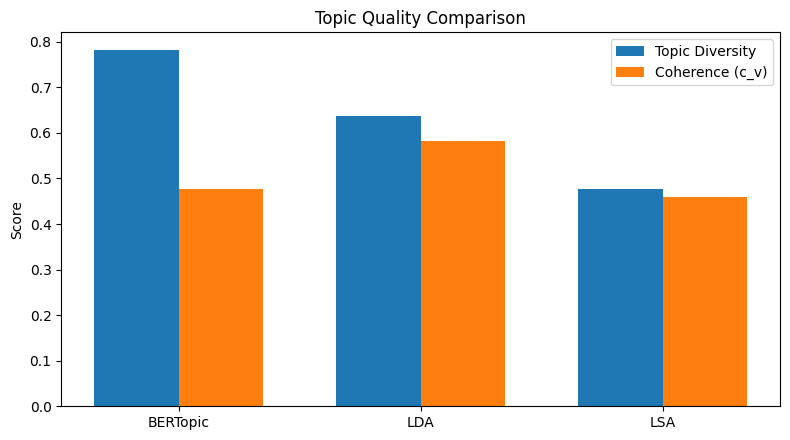

In [7]:
# ------------------------------------------------------------
# Cell 6 — Grouped bar chart: Diversity & Coherence
# ------------------------------------------------------------
import pandas as pd, numpy as np, matplotlib.pyplot as plt
cmp = pd.read_csv(DATA_DIR/"model_comparison.csv")
pivot = cmp.pivot_table(index="model", values=["topic_diversity","coherence_c_v"], aggfunc="mean").sort_index()
x=np.arange(len(pivot)); w=0.35
fig,ax=plt.subplots(figsize=(8,4.5))
ax.bar(x-w/2, pivot["topic_diversity"].values, w, label="Topic Diversity")
ax.bar(x+w/2, pivot["coherence_c_v"].values, w, label="Coherence (c_v)")
ax.set_xticks(x); ax.set_xticklabels(pivot.index); ax.set_ylabel("Score"); ax.set_title("Topic Quality Comparison"); ax.legend()
plt.tight_layout(); plt.show()
